In [3]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os

# Load .env file even though Chicago needs no key
# Good habit to always include this
load_dotenv('../.env')

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
# Chicago Food Inspections — Socrata API
# No key required for this endpoint

url = "https://data.cityofchicago.org/resource/4ijn-s7e5.json"

params = {
    "$limit": 100000,    # rows to pull
    "$offset": 0,       # start from row 0
    "$order": "inspection_date DESC"  # newest first
}

response = requests.get(url, params=params)

# Should print 200 — means success
print("Status code:", response.status_code)

# If you see 200 you are good
# If you see 429 you hit the rate limit — reduce $limit
# If you see 403 you need a key — but you should not see this

Status code: 200


In [5]:
data = response.json()
df = pd.DataFrame(data)

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape: (100000, 17)

Column names:
['inspection_id', 'dba_name', 'aka_name', 'license_', 'risk', 'address', 'city', 'state', 'zip', 'inspection_date', 'inspection_type', 'results', 'latitude', 'longitude', 'location', 'facility_type', 'violations']


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   inspection_id    100000 non-null  str   
 1   dba_name         100000 non-null  str   
 2   aka_name         99869 non-null   str   
 3   license_         99997 non-null   str   
 4   risk             99978 non-null   str   
 5   address          100000 non-null  str   
 6   city             99918 non-null   str   
 7   state            99969 non-null   str   
 8   zip              99990 non-null   str   
 9   inspection_date  100000 non-null  str   
 10  inspection_type  100000 non-null  str   
 11  results          100000 non-null  str   
 12  latitude         99639 non-null   str   
 13  longitude        99639 non-null   str   
 14  location         99639 non-null   object
 15  facility_type    99485 non-null   str   
 16  violations       68755 non-null   str   
dtypes: object(1), str(16)


In [7]:
null_rates = df.isnull().sum()/len(df)*100
print("Null rate per column (%):\n")
print(null_rates.sort_values(ascending=False).round(4))

Null rate per column (%):

violations         31.245
facility_type       0.515
longitude           0.361
location            0.361
latitude            0.361
aka_name            0.131
city                0.082
state               0.031
risk                0.022
zip                 0.010
license_            0.003
inspection_id       0.000
dba_name            0.000
address             0.000
results             0.000
inspection_date     0.000
inspection_type     0.000
dtype: float64


In [8]:

cat_cols = ['results', 'risk', 'facility_type', 'inspection_type']
existing = [c for c in cat_cols if c in df.columns]

for col in existing:
    print(df[col].value_counts())

results
Pass                    50035
Fail                    19158
Pass w/ Conditions      14440
Out of Business          7289
No Entry                 6820
Not Ready                2235
Business Not Located       23
Name: count, dtype: int64
risk
Risk 1 (High)      80121
Risk 2 (Medium)    14745
Risk 3 (Low)        5042
All                   70
Name: count, dtype: int64
facility_type
Restaurant                         70326
Grocery Store                       9621
School                              6497
Children's Services Facility        3595
Daycare Above and Under 2 Years     1527
                                   ...  
HEALTH CARE STORE                      1
MOBILE FOOD DESSERTS VENDOR            1
PRIVATE CLUB                           1
health club                            1
HEALTH FOOD STORE                      1
Name: count, Length: 248, dtype: int64
inspection_type
Canvass                                   48755
License                                   13914
Canvass R

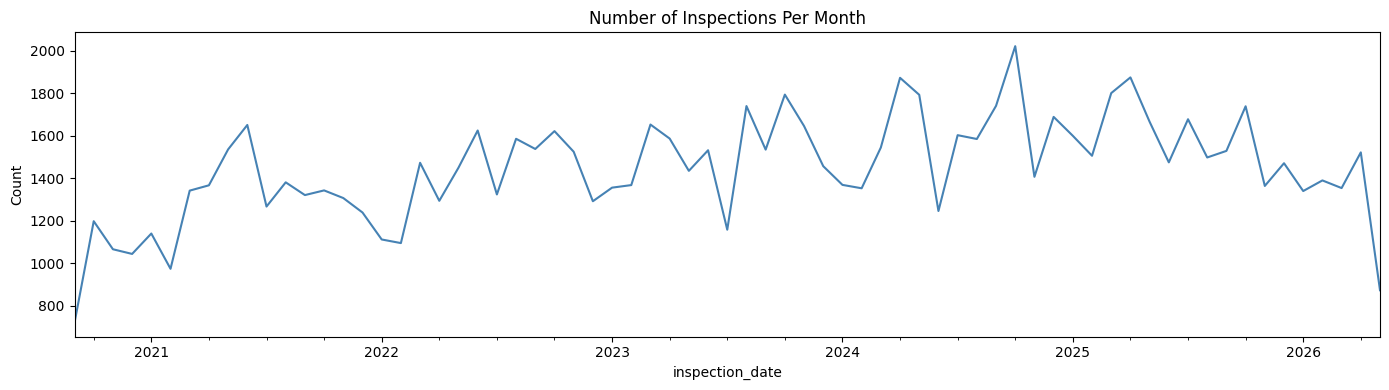

In [9]:
df['inspection_date'] = pd.to_datetime(df['inspection_date'])

df.set_index('inspection_date').resample('ME')['results'].count().plot(
    figsize=(14, 4),
    title='Number of Inspections Per Month',
    color='steelblue'
)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

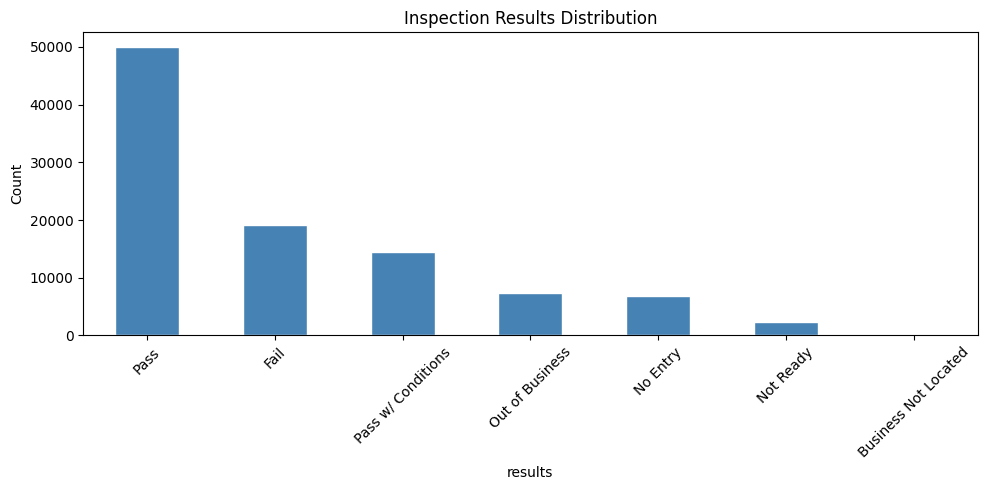

In [10]:
df['results'].value_counts().plot(
    kind='bar',
    figsize=(10, 5),
    title='Inspection Results Distribution',
    color='steelblue',
    edgecolor='white'
)
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

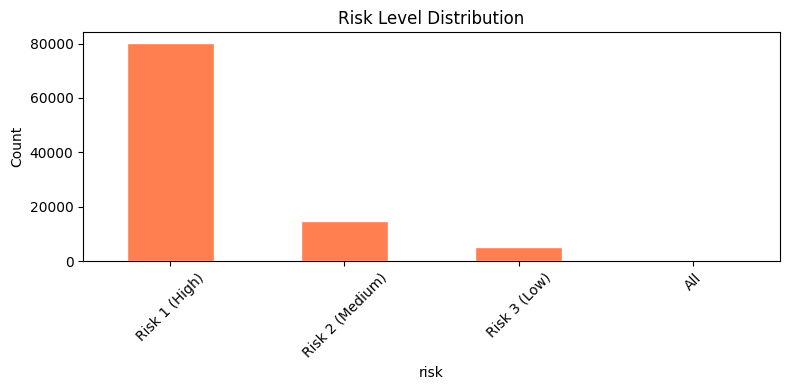

In [11]:
df['risk'].value_counts().plot(
    kind='bar',
    figsize=(8, 4),
    title='Risk Level Distribution',
    color='coral',
    edgecolor='white'
)
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Numeric columns:", num_cols)

if num_cols:
    print(df[num_cols].describe().round(2))
else:
    print("No numeric columns found")
    print("Main detectors for this dataset: schema drift + null rate monitor only")

Numeric columns: []
No numeric columns found
Main detectors for this dataset: schema drift + null rate monitor only


In [13]:
import os
os.makedirs('../data/raw', exist_ok=True)
df.to_csv('../data/raw/chicago_food.csv', index=False)
print(f"Saved {len(df):,} rows to data/raw/chicago_food.csv")

Saved 100,000 rows to data/raw/chicago_food.csv


## EDA Findings — Chicago Food Inspections

### Shape
- Rows: 100,000
- Columns: 17
- All columns are string type except location (object/nested dict)
- No numeric columns — Isolation Forest not applicable

### Null rates — baseline
- violations: 31.245%  ← natural, not every inspection has violations
- facility_type: 0.515%
- longitude: 0.361%
- location: 0.361%
- latitude: 0.361%
- aka_name: 0.131%
- city: 0.082%
- state: 0.031%
- risk: 0.022%
- zip: 0.010%
- license_: 0.003%
- inspection_id: 0.0%
- dba_name: 0.0%
- address: 0.0%
- results: 0.0%
- inspection_date: 0.0%
- inspection_type: 0.0%
- Alert threshold: null rate jump above 10% from baseline

### Known categories — schema drift baseline
#### results (7 values)
- Pass
- Fail
- Pass w/ Conditions
- Out of Business
- No Entry
- Not Ready
- Business Not Located

#### risk (4 values)
- Risk 1 (High)
- Risk 2 (Medium)
- Risk 3 (Low)
- All

#### inspection_type (17 values)
- Canvass
- License
- Canvass Re-Inspection
- Complaint
- Non-Inspection
- Complaint Re-Inspection
- License Re-Inspection
- Short Form Complaint
- Recent Inspection
- Suspected Food Poisoning
- Suspected Food Poisoning Re-inspection
- Not Ready
- Consultation
- Special Events (Festivals)
- ASSESSMENT (possible data entry error — all caps)
- NO ENTRY (possible data entry error — all caps)
- OUT OF BUSINESS (possible data entry error — all caps)

#### facility_type
- 248 unique values — too many to protect strictly
- Detector strategy: alert only on completely new format
  not on every new facility type name

### What detectors run on this dataset
- schema_drift: YES — main purpose
- null_rate_monitor: YES
- isolation_forest: NO — no numeric columns
- distribution_drift: NO — no numeric columns
- timeseries: NO — not applicable

### Special notes
- latitude and longitude come as strings from API
  must convert to float in connector
- location column is nested dict — flatten in connector
- inspection_type has 3 all-caps values that look like
  data entry errors — document as known baseline quirks
- violations 31% null is completely normal for this dataset